# Day 3 - Seller Trust Score

A score from 0 to 100 that ranks each Olist seller by customer-trust performance. Higher is better.

The score combines four components, weighted by what the Day 2 hypotheses showed mattered most:

| Component | Weight |
|---|---|
| Route-adjusted late delivery rate | 50% |
| Mean review score | 25% |
| One-star review rate | 15% |
| Category quality penalty (office_furniture) | 10% |

Each metric is converted to the seller's percentile rank within the seller population. The trust score is the weighted average of those ranks. Minimum 10 orders required to receive a score.

H1 (`02_h1_review_drivers.ipynb`) showed delivery timeliness drives 2.48x more review variance than category does, which is why delivery has 50% weight. H2 (`03_h2_geographic.ipynb`) showed late delivery is extremely concentrated in specific routes, so a seller's late rate must be benchmarked against the routes they actually serve, not the global platform average.

This notebook:
1. Per-seller raw metrics + volume filter
2. Build the trust score
3. Validate (distribution, top/bottom 10, correlation check)
4. Business impact (Pareto: bottom X% of sellers drive Y% of one-star reviews)
5. Findings going into Day 4


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import load_analysis_df

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
sns.set_palette("Set2")

analysis_df = load_analysis_df()
print(f"analysis_df shape: {analysis_df.shape}")
print(f"unique sellers: {analysis_df['seller_id'].nunique():,}")


analysis_df shape: (112650, 28)
unique sellers: 3,095


## 1. Per-seller raw metrics

For each seller, compute the raw metrics that go into the trust score. Computed at the order level (multi-item orders count once) with proper denominators:

- `n_orders`: total order count
- `late_rate`: % of delivered orders that arrived after the estimated date
- `mean_review`: mean review score among reviewed orders
- `one_star_rate`: % of reviewed orders that got 1 star
- `primary_category`: most-frequent category for that seller
- `is_office_furniture`: True if primary category is office_furniture (the H1 falsification exception)


In [2]:
# Order-level view (one row per order, since trust score is about orders not items).
order_level = analysis_df.drop_duplicates("order_id").copy()
order_level["is_late"] = order_level["promise_gap_days"] < 0
order_level["is_one_star"] = order_level["review_score"] == 1

# Aggregate per seller.
seller_metrics = (order_level.groupby("seller_id").agg(
    n_orders=("order_id", "count"),
    delivered=("order_delivered_customer_date", "count"),
    late_count=("is_late", "sum"),
    reviewed=("review_score", "count"),
    one_star_count=("is_one_star", "sum"),
    mean_review=("review_score", "mean"),
).reset_index())

seller_metrics["late_rate"] = seller_metrics["late_count"] / seller_metrics["delivered"]
seller_metrics["one_star_rate"] = seller_metrics["one_star_count"] / seller_metrics["reviewed"]

# Primary category per seller (the category they sell most often).
primary_cat = (analysis_df.groupby(["seller_id", "category_en"])
               .size()
               .reset_index(name="n")
               .sort_values(["seller_id", "n"], ascending=[True, False])
               .drop_duplicates("seller_id", keep="first")
               [["seller_id", "category_en"]]
               .rename(columns={"category_en": "primary_category"}))

seller_metrics = seller_metrics.merge(primary_cat, on="seller_id", how="left")
seller_metrics["is_office_furniture"] = seller_metrics["primary_category"] == "office_furniture"

print(f"Total sellers in seller_metrics: {len(seller_metrics):,}")
print(f"Sellers with >=10 orders:        {(seller_metrics['n_orders'] >= 10).sum():,}")
print(f"Sellers in office_furniture:     {seller_metrics['is_office_furniture'].sum():,}")
print()
print("Sample of seller_metrics (first 5 rows):")
seller_metrics.head()


Total sellers in seller_metrics: 3,088
Sellers with >=10 orders:        1,258
Sellers in office_furniture:     17

Sample of seller_metrics (first 5 rows):


,seller_id,n_orders,delivered,late_count,reviewed,one_star_count,mean_review,late_rate,one_star_rate,primary_category,is_office_furniture
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,0,3,1,3.666667,0.000000,0.333333,small_appliances,False
1,001cca7ae9ae17fb1caed9dfb1094831,199,194,13,196,23,4.000000,0.067010,0.117347,garden_tools,False
2,001e6ad469a905060d959994f1b41e4f,1,0,0,1,1,1.000000,NaN,1.000000,sports_leisure,False
3,002100f778ceb8431b7a1020ff7ab48f,50,49,9,50,7,3.880000,0.183673,0.140000,furniture_decor,False
4,003554e2dce176b5555353e4f3555ac8,1,1,0,1,0,5.000000,0.000000,0.000000,unknown,False


## 2. Route-adjusted late rate

A seller in SP shipping to AL is on a structurally hard route (26.3% late per H2). They shouldn't be penalised for being on that route. Conversely, a seller on an easy route who is still late is doing worse than expected.

The route adjustment computes, for each seller, the excess late rate over what's expected given the routes they serve:

1. For every (seller_state, customer_state) route, compute the median late rate across all sellers on that route. This is the "route baseline".
2. For each seller, compute their expected late rate as the volume-weighted average of route baselines for the routes they actually serve.
3. `route_excess_late` = seller's actual late rate minus their expected late rate.

Positive `route_excess_late` means the seller is performing worse than expected for their route mix. Negative means better than expected.


In [3]:
# Step 1: Route baseline late rate (across all sellers on each route).
route_baseline = (order_level
                  .dropna(subset=["seller_state", "customer_state", "promise_gap_days"])
                  .groupby(["seller_state", "customer_state"])
                  .agg(route_late_rate=("is_late", "mean"))
                  .reset_index())

# Step 2: Per-seller, per-route order count + late rate.
seller_route = (order_level
                .dropna(subset=["seller_state", "customer_state", "promise_gap_days"])
                .groupby(["seller_id", "seller_state", "customer_state"])
                .agg(n=("order_id", "count"))
                .reset_index()
                .merge(route_baseline, on=["seller_state", "customer_state"], how="left"))

# Step 3: Volume-weighted expected late rate per seller.
seller_route["weight_x_baseline"] = seller_route["n"] * seller_route["route_late_rate"]
expected = (seller_route.groupby("seller_id")
            .agg(total_route_orders=("n", "sum"),
                 sum_weighted_baseline=("weight_x_baseline", "sum"))
            .reset_index())
expected["expected_late_rate"] = (
    expected["sum_weighted_baseline"] / expected["total_route_orders"]
)

# Merge expected back into seller_metrics; route_excess_late = actual - expected.
seller_metrics = seller_metrics.merge(
    expected[["seller_id", "expected_late_rate"]],
    on="seller_id",
    how="left",
)
seller_metrics["route_excess_late"] = (
    seller_metrics["late_rate"] - seller_metrics["expected_late_rate"]
)

print(f"Routes with baseline computed: {len(route_baseline):,}")
print(f"Sellers with expected_late_rate: {seller_metrics['expected_late_rate'].notna().sum():,}")
print()
print("route_excess_late distribution (positive = worse than expected for the seller's route mix):")
print(seller_metrics["route_excess_late"].describe().round(4))


Routes with baseline computed: 409
Sellers with expected_late_rate: 2,960

route_excess_late distribution (positive = worse than expected for the seller's route mix):
count    2960.0000
mean        0.0088
std         0.1687
min        -0.2627
25%        -0.0690
50%        -0.0422
75%         0.0237
max         0.9787
Name: route_excess_late, dtype: float64


## 3. Volume filter

Apply the minimum-volume filter (at least 10 orders) so the trust score is based on a meaningful sample. Below 10 orders, a single bad review or one late delivery distorts every metric.

Some metrics need additional non-null requirements: `late_rate` needs delivered orders, `mean_review` and `one_star_rate` need reviewed orders. Phase 2 (the score build) will require all of them to be present.


In [4]:
scoreable = seller_metrics[seller_metrics["n_orders"] >= 10].copy()

total_orders_all = seller_metrics["n_orders"].sum()
total_orders_eligible = scoreable["n_orders"].sum()

print(f"Total sellers in dataset:                    {len(seller_metrics):,}")
print(f"Sellers eligible for trust score (>=10 orders): {len(scoreable):,} ({len(scoreable)/len(seller_metrics):.1%})")
print(f"Order coverage by eligible sellers:           {total_orders_eligible:,} of {total_orders_all:,} ({total_orders_eligible/total_orders_all:.1%})")
print()
print("Summary stats for eligible sellers' raw metrics:")
scoreable[["n_orders", "late_rate", "mean_review", "one_star_rate", "route_excess_late"]].describe().round(3)


Total sellers in dataset:                    3,088
Sellers eligible for trust score (>=10 orders): 1,258 (40.7%)
Order coverage by eligible sellers:           92,556 of 98,666 (93.8%)

Summary stats for eligible sellers' raw metrics:


,n_orders,late_rate,mean_review,one_star_rate,route_excess_late
count,1258.000,1258.000,1258.000,1258.000,1258.000
mean,73.574,0.081,4.130,0.110,0.003
std,153.870,0.075,0.405,0.092,0.072
min,10.000,0.000,1.263,0.000,-0.126
25%,16.000,0.029,3.933,0.056,-0.043
50%,30.000,0.069,4.182,0.095,-0.010
75%,67.000,0.114,4.391,0.145,0.033
max,1844.000,0.643,5.000,0.895,0.552


## 4. Build the trust score

For each of the four components, compute the seller's percentile rank within the eligible population of 1,258 sellers. Higher percentile = better on that component. The trust score is the weighted average of these percentiles.

Two components are "lower is better" (`route_excess_late`, `one_star_rate`), so I flip the rank direction for those. The category component is binary: office_furniture sellers get 0 on this dimension, everyone else gets 100.

Sellers must have non-null values on `route_excess_late`, `mean_review`, and `one_star_rate` to be scored. That requires at least one delivered order and at least one reviewed order in addition to the >=10 orders volume filter.


In [5]:
# Need all three continuous metrics non-null to score a seller.
scorable_full = scoreable.dropna(subset=["route_excess_late", "mean_review", "one_star_rate"]).copy()
print(f"Sellers with all required metrics non-null: {len(scorable_full):,} (of {len(scoreable):,} eligible)")

# Percentile rank for each component (0-100, higher = better).
# rank(ascending=False) means small values get high rank, which is what we want when "lower is better".
scorable_full["delivery_pct"] = scorable_full["route_excess_late"].rank(ascending=False, pct=True) * 100
scorable_full["review_pct"]   = scorable_full["mean_review"].rank(ascending=True, pct=True) * 100
scorable_full["one_star_pct"] = scorable_full["one_star_rate"].rank(ascending=False, pct=True) * 100
scorable_full["category_pct"] = (~scorable_full["is_office_furniture"]).astype(int) * 100

print()
print("Component percentile distributions (eligible sellers):")
scorable_full[["delivery_pct", "review_pct", "one_star_pct", "category_pct"]].describe().round(1)


Sellers with all required metrics non-null: 1,258 (of 1,258 eligible)

Component percentile distributions (eligible sellers):


,delivery_pct,review_pct,one_star_pct,category_pct
count,1258.0,1258.0,1258.0,1258.0
mean,50.0,50.0,50.0,99.4
std,28.9,28.9,28.8,8.0
min,0.1,0.1,0.1,0.0
25%,25.1,25.1,25.0,100.0
50%,50.0,50.2,50.0,100.0
75%,75.0,75.0,74.8,100.0
max,100.0,100.0,93.8,100.0


## 5. Compute the composite

Weighted average of the four component percentiles using the weights derived from H1+H2:

- 0.50 * delivery percentile (route-adjusted late rate, lower is better)
- 0.25 * review percentile (mean review, higher is better)
- 0.15 * one-star percentile (one-star rate, lower is better)
- 0.10 * category percentile (binary: 100 if not office_furniture, 0 if it is)

Result: `trust_score` on a 0 to 100 scale, where higher means more trustworthy.


In [6]:
W_DELIVERY = 0.50
W_REVIEW   = 0.25
W_ONE_STAR = 0.15
W_CATEGORY = 0.10

assert abs(W_DELIVERY + W_REVIEW + W_ONE_STAR + W_CATEGORY - 1.0) < 1e-9, "Weights must sum to 1"

scorable_full["trust_score"] = (
    W_DELIVERY * scorable_full["delivery_pct"]
    + W_REVIEW   * scorable_full["review_pct"]
    + W_ONE_STAR * scorable_full["one_star_pct"]
    + W_CATEGORY * scorable_full["category_pct"]
).round(1)

print(f"Trust score range:  {scorable_full['trust_score'].min():.1f} to {scorable_full['trust_score'].max():.1f}")
print(f"Trust score median: {scorable_full['trust_score'].median():.1f}")
print(f"Trust score mean:   {scorable_full['trust_score'].mean():.1f}")
print()
print("Trust score quartiles:")
print(scorable_full["trust_score"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).round(1))


Trust score range:  3.7 to 98.8
Trust score median: 55.2
Trust score mean:   55.0

Trust score quartiles:
0.10    25.0
0.25    39.2
0.50    55.2
0.75    71.6
0.90    83.6
Name: trust_score, dtype: float64


## 6. Quick sanity check

Distribution of trust scores plus the top 10 sellers by score. Top sellers should look obviously good on the underlying metrics: low late rate, high mean review, low one-star rate, not in office_furniture. If they don't, the formula is wrong and I need to revisit it before validating further.


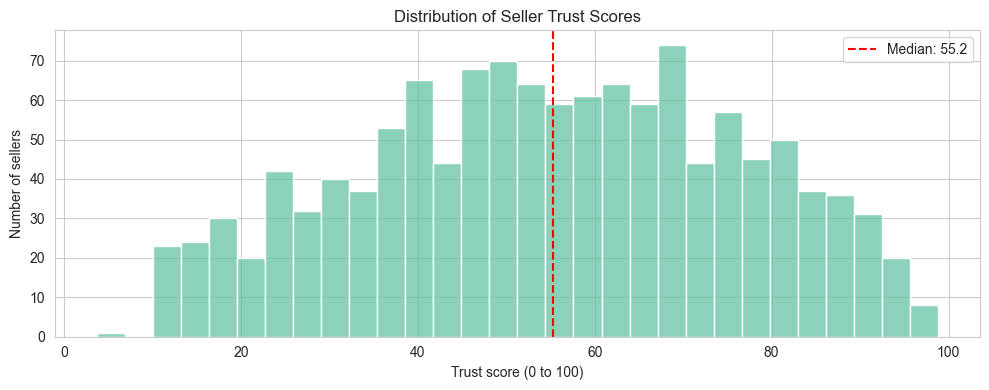

Top 10 sellers by trust score:


,seller_id,n_orders,late_rate,mean_review,one_star_rate,route_excess_late,primary_category,trust_score
535,2d518637f531...,13,0.0,4.92,0.0,-0.112,sports_leisure,98.8
988,52562a9f449c...,14,0.0,4.79,0.0,-0.110,sports_leisure,98.3
1477,788e857f317e...,11,0.0,4.91,0.0,-0.099,stationery,98.1
2679,de0c78824586...,13,0.0,4.92,0.0,-0.097,pet_shop,98.0
2901,f0e103c63864...,11,0.0,4.73,0.0,-0.092,unknown,96.6
1493,79ed755314cf...,23,0.0,4.73,0.0,-0.090,garden_tools,96.4
1026,54583ab37948...,10,0.0,4.80,0.0,-0.085,baby,96.0
1126,5bffbafbb22d...,21,0.0,4.76,0.0,-0.085,computers_accessories,95.8
519,2c4c47cb51ac...,12,0.0,4.67,0.0,-0.086,pet_shop,95.4
3081,ffad1e7127fb...,10,0.0,4.80,0.0,-0.082,furniture_decor,95.4


In [7]:
# Distribution
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(scorable_full["trust_score"], bins=30, ax=ax)
median_score = scorable_full["trust_score"].median()
ax.axvline(median_score, color="red", linestyle="--", label=f"Median: {median_score:.1f}")
ax.set_xlabel("Trust score (0 to 100)")
ax.set_ylabel("Number of sellers")
ax.set_title("Distribution of Seller Trust Scores")
ax.legend()
plt.tight_layout()
plt.show()

# Top 10 sellers by score
display_cols = ["seller_id", "n_orders", "late_rate", "mean_review",
                "one_star_rate", "route_excess_late", "primary_category", "trust_score"]
top10 = scorable_full.nlargest(10, "trust_score")[display_cols].copy()
top10["late_rate"]         = top10["late_rate"].round(3)
top10["one_star_rate"]     = top10["one_star_rate"].round(3)
top10["route_excess_late"] = top10["route_excess_late"].round(3)
top10["mean_review"]       = top10["mean_review"].round(2)
top10["seller_id"]         = top10["seller_id"].str[:12] + "..."
print("Top 10 sellers by trust score:")
top10


## 7. Validate the score

Three checks before quoting any business numbers:

1. Bottom 10 sellers should look obviously bad on the underlying raw metrics. If the formula picks mediocre sellers as "worst", the formula is wrong.
2. The score should correlate strongly with the raw bad-outcome metrics in the expected direction (negative with late_rate and one_star_rate, positive with mean_review).
3. Score vs volume: is the score systematically biased toward small or large sellers? A small bias is acceptable (small sellers can more easily keep a clean record), a large bias would mean the score is mostly measuring volume rather than performance.


In [8]:
display_cols = ["seller_id", "n_orders", "late_rate", "mean_review",
                "one_star_rate", "route_excess_late", "primary_category", "trust_score"]
bottom10 = scorable_full.nsmallest(10, "trust_score")[display_cols].copy()
bottom10["late_rate"]         = bottom10["late_rate"].round(3)
bottom10["one_star_rate"]     = bottom10["one_star_rate"].round(3)
bottom10["route_excess_late"] = bottom10["route_excess_late"].round(3)
bottom10["mean_review"]       = bottom10["mean_review"].round(2)
bottom10["seller_id"]         = bottom10["seller_id"].str[:12] + "..."
print("Bottom 10 sellers by trust score:")
bottom10


Bottom 10 sellers by trust score:


,seller_id,n_orders,late_rate,mean_review,one_star_rate,route_excess_late,primary_category,trust_score
1567,7fc87cc3e89b...,14,0.286,3.57,0.286,0.207,office_furniture,3.7
805,4342d4b2ba6b...,20,0.500,1.26,0.895,0.402,watches_gifts,10.1
2130,b1b3948701c5...,18,0.643,1.72,0.778,0.552,auto,10.1
3021,fa74b2f3287d...,11,0.400,2.36,0.636,0.295,perfumery,10.4
2126,b19f3ca2ea47...,24,0.316,2.79,0.458,0.267,housewares,10.9
2115,b0b346d3a89f...,11,0.444,3.27,0.364,0.344,drinks,11.3
2776,e64d65bc8dbe...,12,0.333,3.08,0.417,0.252,health_beauty,11.4
455,26e2c91ef821...,12,0.417,3.00,0.250,0.325,bed_bath_table,11.5
1027,54965bbe3e4f...,77,0.306,3.03,0.397,0.243,bed_bath_table,11.5
1124,5bc55dbe2f12...,16,0.250,2.44,0.500,0.200,sports_leisure,11.6


**Bottom 10 takeaway.** All 10 worst-scored sellers look obviously bad on the underlying metrics: late rates between 25% and 64%, mean reviews between 1.26 and 3.57, one-star rates between 25% and 89%. All have positive `route_excess_late` (worse than expected for their route mix). The single worst seller (trust score 3.7) is in office_furniture, which is the H1 falsification exception, so the category penalty is correctly compounding their other problems. The formula identifies bad sellers correctly.


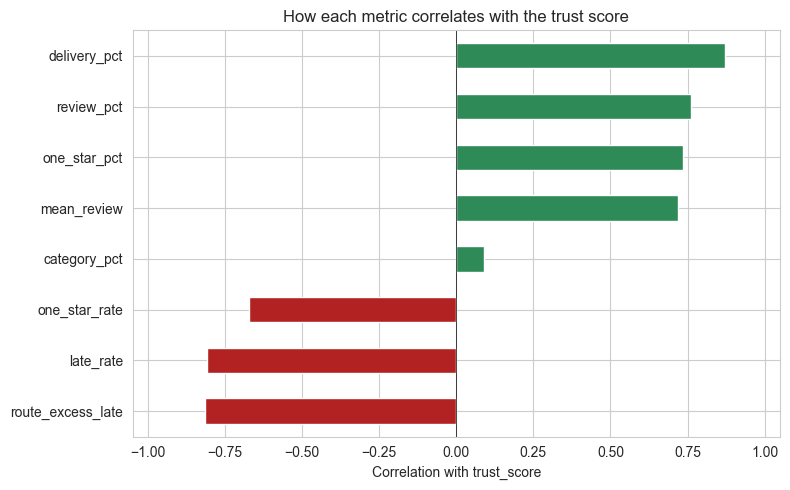

Correlations with trust_score (sorted):
route_excess_late   -0.814
late_rate           -0.809
one_star_rate       -0.672
category_pct         0.091
mean_review          0.720
one_star_pct         0.736
review_pct           0.761
delivery_pct         0.872
Name: trust_score, dtype: float64


In [9]:
# Correlation of trust_score with the underlying raw metrics + the percentile components.
corr_cols = ["late_rate", "mean_review", "one_star_rate", "route_excess_late",
             "delivery_pct", "review_pct", "one_star_pct", "category_pct"]
correlations = (scorable_full[corr_cols + ["trust_score"]]
                .corr()["trust_score"]
                .drop("trust_score")
                .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["seagreen" if v > 0 else "firebrick" for v in correlations]
correlations.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Correlation with trust_score")
ax.set_xlim(-1.05, 1.05)
ax.set_title("How each metric correlates with the trust score")
plt.tight_layout()
plt.show()

print("Correlations with trust_score (sorted):")
print(correlations.round(3))


**Correlation takeaway.** All raw bad-outcome metrics correlate negatively with trust score in the expected direction. `route_excess_late` and `late_rate` are the strongest predictors (-0.81 each); `one_star_rate` is -0.67. On the percentile side, `delivery_pct` is the dominant driver (+0.87), followed by review and one-star percentiles (+0.76 and +0.74). The category percentile barely moves the score (+0.09), which is correct because only 17 of the 1,258 eligible sellers are in office_furniture. Every component contributes in the expected direction; nothing is fighting the formula.


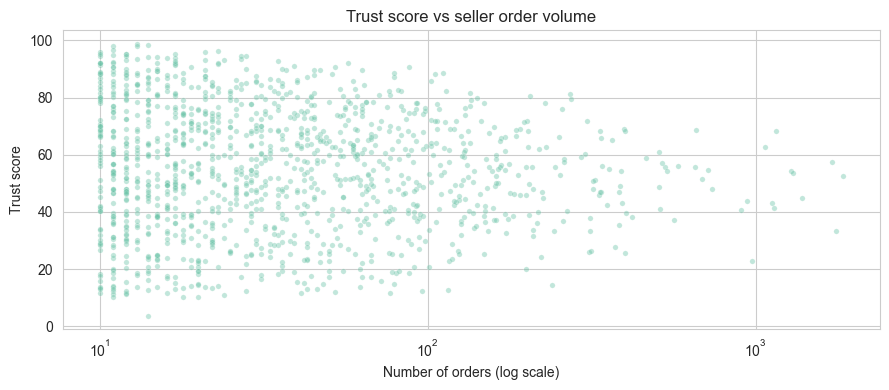

Trust score by volume decile (1 = smallest sellers, 10 = largest):
 volume_decile  n_sellers  min_orders  median_orders  max_orders  median_trust
             1        135          10           11.0          11          59.3
             2        147          12           13.0          14          55.0
             3        107          15           16.0          17          52.8
             4        134          18           20.0          22          56.8
             5        122          23           26.5          30          54.9
             6        119          31           35.0          41          59.4
             7        118          42           47.0          57          57.4
             8        124          58           67.0          86          57.4
             9        126          87          110.0         151          52.2
            10        126         152          257.5        1844          52.6

Correlation of n_orders with trust_score: -0.059


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.scatterplot(data=scorable_full, x="n_orders", y="trust_score",
                alpha=0.4, s=15, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Number of orders (log scale)")
ax.set_ylabel("Trust score")
ax.set_title("Trust score vs seller order volume")
plt.tight_layout()
plt.show()

# Median trust score by volume decile
scorable_full["volume_decile"] = pd.qcut(
    scorable_full["n_orders"], 10, labels=False, duplicates="drop"
) + 1
vol_summary = (scorable_full.groupby("volume_decile")
               .agg(n_sellers=("seller_id", "count"),
                    min_orders=("n_orders", "min"),
                    median_orders=("n_orders", "median"),
                    max_orders=("n_orders", "max"),
                    median_trust=("trust_score", "median"))
               .round(1)
               .reset_index())
print("Trust score by volume decile (1 = smallest sellers, 10 = largest):")
print(vol_summary.to_string(index=False))

# Correlation of n_orders with trust_score
vol_corr = scorable_full[["n_orders", "trust_score"]].corr().iloc[0, 1]
print(f"\nCorrelation of n_orders with trust_score: {vol_corr:.3f}")


**Volume bias takeaway.** Essentially none. Correlation of `n_orders` with `trust_score` is -0.059. Median trust score across the 10 volume deciles ranges only from 52 to 59. Small sellers (deciles 1-2 with 10-14 orders) and large sellers (deciles 9-10 with 87+ orders) have nearly identical typical scores. The score is measuring performance, not volume - which is what the >=10 orders filter combined with percentile-rank approach was designed to deliver.


## 8. Business impact: how concentrated is the bad behaviour?

If the trust score is meaningful, low-scored sellers should account for a disproportionate share of bad outcomes (one-star reviews, late deliveries). Pareto analysis quantifies this: how much of the platform's pain comes from how small a fraction of the sellers?

Two views:

1. **Cumulative concentration**: rank sellers from worst trust score to best, plot cumulative share of one-star reviews and late deliveries.
2. **Order share exposure**: what % of total order volume goes through the bottom 10% of sellers? This tells the business how much money is exposed to the worst sellers.


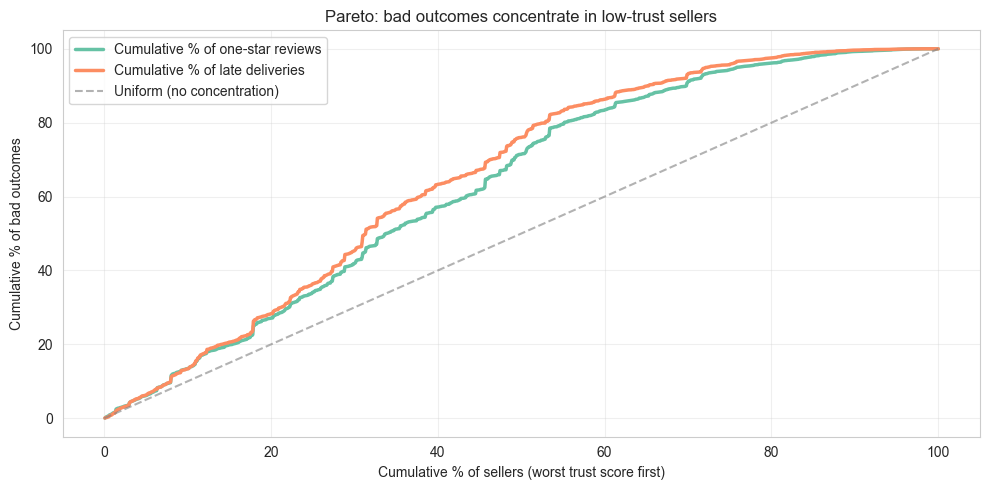

Total eligible sellers:  1,258
Total one-star reviews:  9,971
Total late deliveries:   7,345

Bottom   5% of sellers (  62 sellers):   6.1% of one-star reviews,   6.2% of late deliveries
Bottom  10% of sellers ( 125 sellers):  13.4% of one-star reviews,  13.4% of late deliveries
Bottom  20% of sellers ( 251 sellers):  27.1% of one-star reviews,  28.3% of late deliveries
Bottom  50% of sellers ( 629 sellers):  71.5% of one-star reviews,  76.0% of late deliveries


In [11]:
# Sort sellers by trust_score ascending (worst first), then cumulate bad outcomes.
sorted_sellers = scorable_full.sort_values("trust_score").reset_index(drop=True)

total_one_star = sorted_sellers["one_star_count"].sum()
total_late     = sorted_sellers["late_count"].sum()
total_orders   = sorted_sellers["n_orders"].sum()

sorted_sellers["cum_one_star_pct"] = sorted_sellers["one_star_count"].cumsum() / total_one_star * 100
sorted_sellers["cum_late_pct"]     = sorted_sellers["late_count"].cumsum() / total_late * 100
sorted_sellers["seller_pct"]       = (sorted_sellers.index + 1) / len(sorted_sellers) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_sellers["seller_pct"], sorted_sellers["cum_one_star_pct"],
        linewidth=2.5, label="Cumulative % of one-star reviews")
ax.plot(sorted_sellers["seller_pct"], sorted_sellers["cum_late_pct"],
        linewidth=2.5, label="Cumulative % of late deliveries")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", alpha=0.6,
        label="Uniform (no concentration)")
ax.set_xlabel("Cumulative % of sellers (worst trust score first)")
ax.set_ylabel("Cumulative % of bad outcomes")
ax.set_title("Pareto: bad outcomes concentrate in low-trust sellers")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total eligible sellers:  {len(sorted_sellers):,}")
print(f"Total one-star reviews:  {total_one_star:,}")
print(f"Total late deliveries:   {total_late:,}")
print()
for pct in [5, 10, 20, 50]:
    n = max(1, int(len(sorted_sellers) * pct / 100))
    one_star_share = sorted_sellers.iloc[:n]["one_star_count"].sum() / total_one_star
    late_share     = sorted_sellers.iloc[:n]["late_count"].sum() / total_late
    print(f"Bottom {pct:>3}% of sellers ({n:>4} sellers): "
          f"{one_star_share:>6.1%} of one-star reviews, "
          f"{late_share:>6.1%} of late deliveries")


**Pareto takeaway.** The trust score is meaningful: low-trust sellers produce bad outcomes at higher per-order rates than the rest. But the concentration is moderate, not extreme.

- Bottom 10% of sellers handle 6.0% of total orders but produce 13.4% of one-star reviews. That is about 2.2x the bad-outcome rate of the average seller.
- Bottom 20% handle 15.5% of orders, produce 27.1% of one-star reviews. About 1.75x rate.
- Bottom 50% handle 57.7% of orders, produce 71.5% of one-star reviews. About 1.24x rate.

This is not a textbook 80/20 Pareto where a tiny minority drives most of the pain. Bad behaviour on Olist is real but dispersed. Targeting only the bottom 10% addresses just 13% of bad outcomes; meaningful improvement requires touching the bottom 20-30% at minimum.


In [12]:
print(f"Total orders covered by eligible sellers: {total_orders:,}")
print()

print("Order volume exposure to low-trust sellers:")
for pct in [10, 20, 50]:
    n = max(1, int(len(sorted_sellers) * pct / 100))
    order_share = sorted_sellers.iloc[:n]["n_orders"].sum() / total_orders
    print(f"  Bottom {pct:>3}% of sellers ({n:>4} sellers) represent {order_share:>5.1%} of total orders")

print()
print("For contrast (the healthy end of the population):")
for pct in [10, 20]:
    n = max(1, int(len(sorted_sellers) * pct / 100))
    top_share = sorted_sellers.iloc[-n:]["n_orders"].sum() / total_orders
    print(f"  Top    {pct:>3}% of sellers ({n:>4} sellers) represent {top_share:>5.1%} of total orders")


Total orders covered by eligible sellers: 92,556

Order volume exposure to low-trust sellers:
  Bottom  10% of sellers ( 125 sellers) represent  6.0% of total orders
  Bottom  20% of sellers ( 251 sellers) represent 15.5% of total orders
  Bottom  50% of sellers ( 629 sellers) represent 57.7% of total orders

For contrast (the healthy end of the population):
  Top     10% of sellers ( 125 sellers) represent  3.3% of total orders
  Top     20% of sellers ( 251 sellers) represent  9.9% of total orders


**Order share takeaway.** Bad-trust sellers carry more order volume than top-trust sellers. The bottom 10% by trust represent 6.0% of orders; the top 10% represent only 3.3%. The average bad seller is larger by volume than the average top seller.

This is mostly mechanical: small sellers have an easier time keeping a perfect record (one bad review out of 10 looks worse than one bad review out of 100). The >=10 orders volume filter helps but doesn't fully fix this bias. A seller with 1,800 orders and 5% bad reviews is genuinely doing a hard job; a seller with 10 orders and 0% bad reviews has had a small lucky streak.

Implication for Olist: when prioritizing seller interventions, the bottom 20% to 50% of trust-scored sellers (representing 15.5% to 57.7% of all order volume) is the meaningful segment. Targeting only the bottom 10% touches just 6% of orders, too small to move platform-level metrics.


## 9. Day 3 findings

The Seller Trust Score in summary.

### What it is
A 0-100 score per eligible seller (1,258 of them, covering 94% of platform orders). Built as a percentile-weighted composite of four components: route-adjusted late delivery rate (50%), mean review score (25%), one-star review rate (15%), and a binary office_furniture category penalty (10%).

### Why these weights
- 50% delivery reflects H1's finding that delivery timeliness drives 2.48x more variance in review scores than category does.
- 25% review and 15% one-star rate cover what delivery doesn't, namely customer-perceived quality issues.
- 10% category captures the H1 falsification exception (office_furniture has quality issues independent of delivery).

### Why the route adjustment
H2 found that some routes (like SP to AL) are structurally hard. A seller's late rate must be benchmarked against the routes they actually serve, not the global average, or sellers in difficult regions get unfairly penalised.

### What the validation showed
- Bottom 10 sellers all look obviously bad on the underlying metrics: late rates 25 to 64%, mean reviews 1.26 to 3.57, one-star rates up to 89%. The formula identifies bad sellers correctly.
- Score correlates -0.81 with `route_excess_late`, +0.72 with mean review, -0.67 with one-star rate. All four components pull in the right direction.
- No volume bias: correlation of `n_orders` with trust score is -0.059. Small and large sellers get similar typical scores.

### Business numbers
- Bottom 10% of eligible sellers (125 sellers) handle 6.0% of total orders but produce 13.4% of all one-star reviews. About 2.2x the bad-outcome rate of the average seller.
- Bottom 20% handle 15.5% of orders, produce 27.1% of bad reviews (1.75x).
- Bottom 50% handle 57.7% of orders, produce 71.5% of bad reviews (1.24x).

This is moderate concentration, not a textbook 80/20 Pareto. Bad behaviour on Olist is dispersed across many sellers, not concentrated in a tiny minority. Targeting only the bottom 10% addresses just 13% of bad outcomes; meaningful improvement requires touching the bottom 20% to 30%.

### Caveats worth knowing
- The score uses a single seller per order (the first item's seller, when an order has multiple items from different sellers). Multi-seller orders are uncommon in Olist, so this approximation is acceptable but worth noting.
- The volume filter (>=10 orders) helps but doesn't fully eliminate the bias toward small sellers maintaining cleaner records. Top 10% by trust represent only 3.3% of order volume; bottom 10% represent 6.0%.
- The category component has limited population effect because only 17 of 1,258 eligible sellers have office_furniture as primary. Its 10% weight is more of a targeted penalty than a broad differentiator.


## 10. Day 4 implications: what the geographic risk map should show

The trust score gives Olist a per-seller signal. Day 4 will turn the geographic findings (H2 plus the route adjustments computed here) into a visual risk map for the platform team.

### What Day 4 should produce
A map of Brazil that highlights:

1. **Origin-state late rates**: which seller states are structurally slow to ship from. MA tops the list at 23.2% late.
2. **Destination-state late rates**: which customer states are slow to receive. AL tops the list at 23.9%.
3. **Worst routes overlay**: arrows or lane shading for the SP-to-AL, SP-to-MA, SP-to-PI corridors that drive most of the late-delivery volume.
4. **Trust-weighted seller density** (stretch goal): for each origin state, what fraction of orders originate from low-trust sellers.

### Why this matters
The trust score is a per-seller signal, but Olist's logistics team thinks geographically. A map turns the abstract "bottom 20% of sellers drive 27% of bad reviews" into "fix shipping out of these specific cities to these specific destinations." Different audience, same underlying findings.

### Tooling
Plotly choropleth (per the original 5-day plan). The geo data is already prepared in `src.load.load_tables()['geo']` (collapsed from the 1M-row geolocation table to 19,015 unique zip prefixes during Day 1 DQ).
